# Square-Duct 3D Validation

This notebook is intentionally standalone: it reads the raw AMReX plotfiles under `_artifacts/cases`, reconstructs the analytical square-duct solution, and generates the summary tables and figures inline.

It does not depend on `summary.json`, `metrics.json`, or pre-rendered PNG files.

## Theory

We consider steady, fully developed flow in the square duct

$$
(x,y,z) \in [0,L_x] \times [-a,a] \times [-a,a],
$$

with velocity field

$$
\mathbf{u} = (u_x(y,z), 0, 0).
$$

For a constant streamwise driving strength `G`, the governing equation is

$$
\mu \left(\frac{\partial^2 u_x}{\partial y^2} + \frac{\partial^2 u_x}{\partial z^2}\right) = -G,
$$

and the analytical square-duct profile used here is

$$
u_x(y,z) = \frac{16 G a^2}{\mu \pi^3}
\sum_{n=1,3,5,\dots}^{\infty}
\frac{(-1)^{(n-1)/2}}{n^3}
\left[1 - \frac{\cosh\!\left(\dfrac{n\pi z}{2a}\right)}{\cosh\!\left(\dfrac{n\pi}{2}\right)}\right]
\cos\!\left(\frac{n\pi y}{2a}\right).
$$

The validation compares the streamwise-averaged numerical field

$$
\bar{u}_x(y,z) = \frac{1}{N_x} \sum_{m=1}^{N_x} u_x(x_m,y,z)
$$

to the analytical profile through the relative error

$$
E_2 = \left(
\frac{\sum_{j,k}[\bar{u}_x(y_j,z_k)-u_x^{\mathrm{exact}}(y_j,z_k)]^2}
{\sum_{j,k}[u_x^{\mathrm{exact}}(y_j,z_k)]^2}
\right)^{1/2}.
$$

## Workflow

- Run the solver cases with `./run_square_duct_validation.sh`.
- Open this notebook and run all cells.
- The notebook will read the raw cases from `_artifacts/cases/32x32` and `_artifacts/cases/48x48` and rebuild the validation summary directly.

In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import yt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", message="Unable to import Axes3D.*")
plt.rcParams["figure.dpi"] = 130

ROOT = Path(".").resolve()
ART = ROOT / "_artifacts"
CASE_SPECS = [
    {
        "label": "32x32",
        "inputs": ROOT / "inputs",
        "plot_root": ART / "cases" / "32x32",
        "exact_force_x": 1.0e-5,
    },
    {
        "label": "48x48",
        "inputs": ROOT / "inputs",
        "plot_root": ART / "cases" / "48x48",
        "exact_force_x": 1.0e-5,
    },
]


def parse_inputs(path: Path) -> dict[str, list[float]]:
    out: dict[str, list[float]] = {}
    with path.open(encoding="utf-8") as fh:
        for raw in fh:
            line = raw.split("#", 1)[0].strip()
            if not line or "=" not in line:
                continue
            lhs, rhs = [part.strip() for part in line.split("=", 1)]
            vals: list[float] = []
            for tok in rhs.split():
                try:
                    vals.append(float(tok))
                except ValueError:
                    pass
            out[lhs] = vals
    return out


def case_plotfiles(root: Path) -> list[Path]:
    cands = [path for path in sorted(root.glob("plt*")) if path.is_dir() and path.name[3:].isdigit()]
    if not cands:
        raise FileNotFoundError(f"No plotfiles found under {root}")
    return cands


def load_fields(plotfile: Path):
    ds = yt.load(str(plotfile))
    dims = tuple(int(v) for v in ds.domain_dimensions)
    cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=dims)
    rho = np.asarray(cg[("boxlib", "rho")].to_ndarray(), dtype=np.float64)
    ux = np.asarray(cg[("boxlib", "ux")].to_ndarray(), dtype=np.float64)
    left = np.asarray(ds.domain_left_edge, dtype=np.float64)
    right = np.asarray(ds.domain_right_edge, dtype=np.float64)
    dx = (right - left) / np.asarray(dims, dtype=np.float64)
    return ds, rho, ux, left, right, dx


def square_duct_exact(y, z, a, force_x, mu, n_terms=200):
    yy = y[:, None]
    zz = z[None, :]
    out = np.zeros((len(y), len(z)), dtype=np.float64)
    pref = 16.0 * force_x * a * a / (mu * math.pi ** 3)
    for n in range(1, 2 * n_terms, 2):
        alpha = n * math.pi / (2.0 * a)
        x = alpha * a
        ratio = (
            np.exp(alpha * (zz - a)) + np.exp(-alpha * (zz + a))
        ) / (1.0 + np.exp(-2.0 * x))
        sign = -1.0 if (((n - 1) // 2) % 2) else 1.0
        out += sign * (1.0 / (n ** 3)) * (1.0 - ratio) * np.cos(alpha * yy)
    return pref * out


def centerline_from_plane(uavg, z):
    k = int(np.argmin(np.abs(z)))
    return uavg[:, k], float(z[k])


def wall_slip_metrics(y, centerline_num, centerline_exact, a):
    slope_num_lo = float((centerline_num[1] - centerline_num[0]) / (y[1] - y[0]))
    slope_ex_lo = float((centerline_exact[1] - centerline_exact[0]) / (y[1] - y[0]))
    u_wall_num_lo = float(centerline_num[0] + slope_num_lo * (-a - y[0]))
    u_wall_ex_lo = float(centerline_exact[0] + slope_ex_lo * (-a - y[0]))
    slope_num_hi = float((centerline_num[-1] - centerline_num[-2]) / (y[-1] - y[-2]))
    slope_ex_hi = float((centerline_exact[-1] - centerline_exact[-2]) / (y[-1] - y[-2]))
    u_wall_num_hi = float(centerline_num[-1] + slope_num_hi * (a - y[-1]))
    u_wall_ex_hi = float(centerline_exact[-1] + slope_ex_hi * (a - y[-1]))
    return {
        "u_wall_num_lo": u_wall_num_lo,
        "u_wall_exact_lo": u_wall_ex_lo,
        "u_wall_num_hi": u_wall_num_hi,
        "u_wall_exact_hi": u_wall_ex_hi,
        "wall_slip_len_lo": float(u_wall_num_lo / max(abs(slope_num_lo), 1.0e-16)),
        "wall_slip_len_hi": float(u_wall_num_hi / max(abs(slope_num_hi), 1.0e-16)),
    }


def analyze_plotfile(plotfile: Path, nu: float, force_x: float, n_terms=200):
    ds, rho, ux, left, right, dx = load_fields(plotfile)
    y = left[1] + (np.arange(ux.shape[1], dtype=np.float64) + 0.5) * dx[1]
    z = left[2] + (np.arange(ux.shape[2], dtype=np.float64) + 0.5) * dx[2]
    a = 0.5 * (right[1] - left[1])
    rho_mean = float(np.mean(rho))
    mu = rho_mean * nu
    uavg = np.mean(ux, axis=0)
    uexact = square_duct_exact(y, z, a, force_x, mu, n_terms)
    diff = uavg - uexact
    center_num, z0 = centerline_from_plane(uavg, z)
    center_exact = square_duct_exact(y, np.array([z0]), a, force_x, mu, n_terms)[:, 0]
    y_dense = np.linspace(float(y[0]), float(y[-1]), 401, dtype=np.float64)
    center_exact_dense = square_duct_exact(y_dense, np.array([z0]), a, force_x, mu, n_terms)[:, 0]
    j0 = int(np.argmin(np.abs(y)))
    k0 = int(np.argmin(np.abs(z)))
    wall = wall_slip_metrics(y, center_num, center_exact, a)
    return {
        "plotfile": str(plotfile),
        "time": float(ds.current_time),
        "step": int(plotfile.name[3:]),
        "nx": int(ux.shape[0]),
        "ny": int(ux.shape[1]),
        "nz": int(ux.shape[2]),
        "dx": float(dx[0]),
        "dy": float(dx[1]),
        "dz": float(dx[2]),
        "rho_mean": rho_mean,
        "a": float(a),
        "y": y,
        "z": z,
        "uavg": uavg,
        "uexact": uexact,
        "error": diff,
        "center_num": center_num,
        "center_exact": center_exact,
        "centerline_z": float(z0),
        "center_exact_dense_y": y_dense,
        "center_exact_dense": center_exact_dense,
        "u_avg_l2_rel": float(np.linalg.norm(diff) / max(np.linalg.norm(uexact), 1.0e-16)),
        "u_avg_linf_rel": float(np.max(np.abs(diff)) / max(np.max(np.abs(uexact)), 1.0e-16)),
        "centerline_l2_rel": float(np.linalg.norm(center_num - center_exact) / max(np.linalg.norm(center_exact), 1.0e-16)),
        "centerline_linf_rel": float(np.max(np.abs(center_num - center_exact)) / max(np.max(np.abs(center_exact)), 1.0e-16)),
        "u_center_exact": float(uexact[j0, k0]),
        "u_center_numeric": float(uavg[j0, k0]),
        **wall,
    }


def analyze_case(spec, n_terms=200):
    cfg = parse_inputs(spec["inputs"])
    nu = cfg["lbmPhysicalParameters.nu"][0]
    force_x = spec["exact_force_x"]
    history = [analyze_plotfile(plotfile, nu, force_x, n_terms) for plotfile in case_plotfiles(spec["plot_root"])]
    return {
        "label": spec["label"],
        "inputs": str(spec["inputs"]),
        "plot_root": str(spec["plot_root"]),
        "nu": float(nu),
        "force_x": float(force_x),
        "history": history,
        "final": history[-1],
    }


analysis = [analyze_case(spec) for spec in CASE_SPECS]
display(Markdown("Loaded raw square-duct cases directly from `_artifacts/cases`."))
[case["label"] for case in analysis]


/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


yt : [INFO     ] 2026-03-21 18:11:16,229 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-03-21 18:11:16,230 Parameters: domain_dimensions         = [ 8 32 32]


yt : [INFO     ] 2026-03-21 18:11:16,230 Parameters: domain_left_edge          = [  0. -16. -16.]


yt : [INFO     ] 2026-03-21 18:11:16,231 Parameters: domain_right_edge         = [ 8. 16. 16.]


...

yt : [INFO     ] 2026-03-21 18:11:18,136 Parameters: domain_dimensions         = [12 48 48]


yt : [INFO     ] 2026-03-21 18:11:18,137 Parameters: domain_left_edge          = [  0. -16. -16.]


yt : [INFO     ] 2026-03-21 18:11:18,138 Parameters: domain_right_edge         = [ 8. 16. 16.]


Loaded raw square-duct cases directly from `_artifacts/cases`.

['32x32', '48x48']

In [2]:
def pct_rel(num, exact):
    return 100.0 * (num - exact) / exact

rows = [
    "| Case | Grid | Final step | $E_2$ | $L_\infty$ | Center $u_x$ error | Avg. slip length |",
    "| --- | --- | ---: | ---: | ---: | ---: | ---: |",
]

for case in analysis:
    final = case["final"]
    slip = 0.5 * (final["wall_slip_len_lo"] + final["wall_slip_len_hi"])
    center_err = pct_rel(final["u_center_numeric"], final["u_center_exact"])
    rows.append(
        f"| {case['label']} | {final['nx']} x {final['ny']} x {final['nz']} | {final['step']} | "
        f"{final['u_avg_l2_rel']:.6e} | {final['u_avg_linf_rel']:.6e} | {center_err:.4f}% | {slip:.6e} |"
    )

order = math.log(analysis[-1]['final']['u_avg_l2_rel'] / analysis[0]['final']['u_avg_l2_rel']) / math.log(
    analysis[0]['final']['ny'] / analysis[-1]['final']['ny']
)
e2_drop = 100.0 * (1.0 - analysis[-1]['final']['u_avg_l2_rel'] / analysis[0]['final']['u_avg_l2_rel'])
slip_drop = 100.0 * (1.0 - analysis[-1]['final']['wall_slip_len_lo'] / analysis[0]['final']['wall_slip_len_lo'])

display(Markdown("## Summary Table\n" + "\n".join(rows)))
display(Markdown(
    "## Takeaways\n"
    f"- Refining from `32x32` to `48x48` reduces the field relative $L_2$ error by **{e2_drop:.1f}%**.\n"
    f"- The observed order from these two resolutions is **{order:.3f}**.\n"
    f"- The estimated wall slip length drops by about **{slip_drop:.1f}%** between the two cases.\n"
    "- The center velocity remains very close to the analytical value in both runs."
))


## Summary Table
| Case | Grid | Final step | $E_2$ | $L_\infty$ | Center $u_x$ error | Avg. slip length |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| 32x32 | 8 x 32 x 32 | 6000 | 8.532900e-04 | 6.523227e-04 | -0.0523% | 3.167683e-02 |
| 48x48 | 12 x 48 x 48 | 9000 | 6.127799e-04 | 7.252013e-04 | -0.0725% | 1.585180e-02 |

## Takeaways
- Refining from `32x32` to `48x48` reduces the field relative $L_2$ error by **28.2%**.
- The observed order from these two resolutions is **0.817**.
- The estimated wall slip length drops by about **50.0%** between the two cases.
- The center velocity remains very close to the analytical value in both runs.

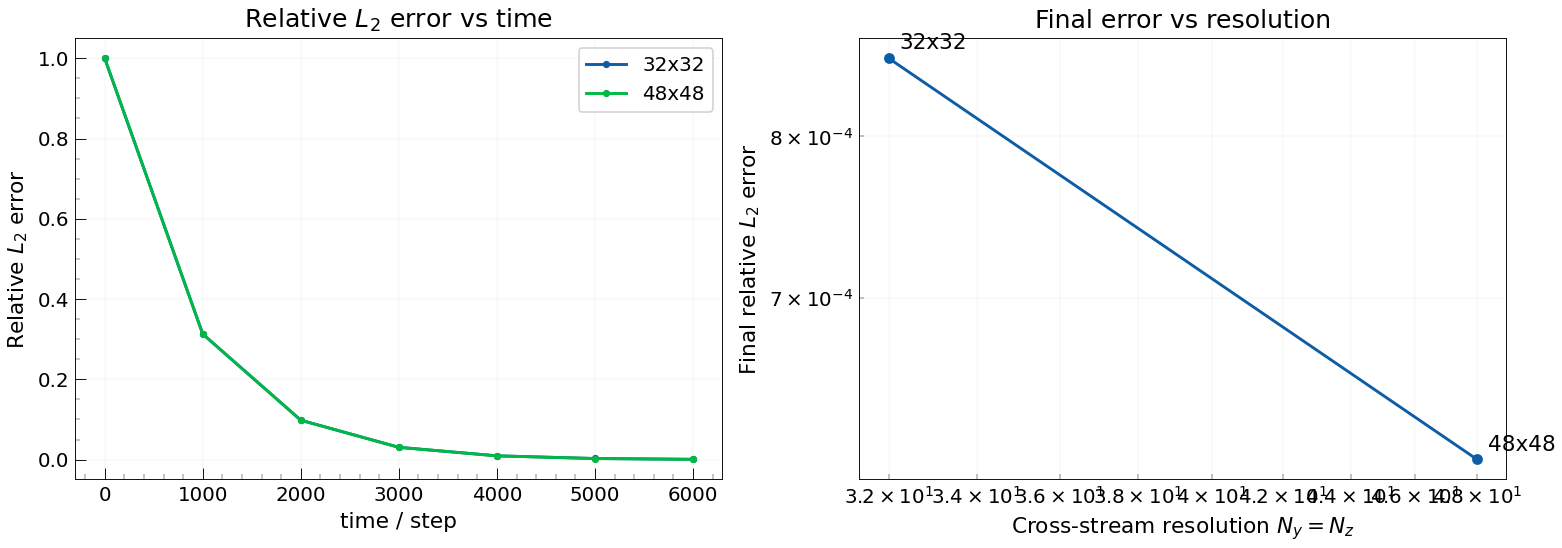

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for case in analysis:
    hist = case['history']
    ax[0].plot([item['time'] for item in hist], [item['u_avg_l2_rel'] for item in hist], marker='o', lw=1.6, ms=4, label=case['label'])

ny = np.asarray([case['final']['ny'] for case in analysis], dtype=np.float64)
e2 = np.asarray([case['final']['u_avg_l2_rel'] for case in analysis], dtype=np.float64)
ax[1].loglog(ny, e2, marker='o', lw=1.6)
for x, y, case in zip(ny, e2, analysis):
    ax[1].annotate(case['label'], (x, y), textcoords='offset points', xytext=(6, 5))

ax[0].set_title('Relative $L_2$ error vs time')
ax[0].set_xlabel('time / step')
ax[0].set_ylabel('Relative $L_2$ error')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].set_title('Final error vs resolution')
ax[1].set_xlabel('Cross-stream resolution $N_y = N_z$')
ax[1].set_ylabel('Final relative $L_2$ error')
ax[1].grid(alpha=0.25, which='both')

plt.show()


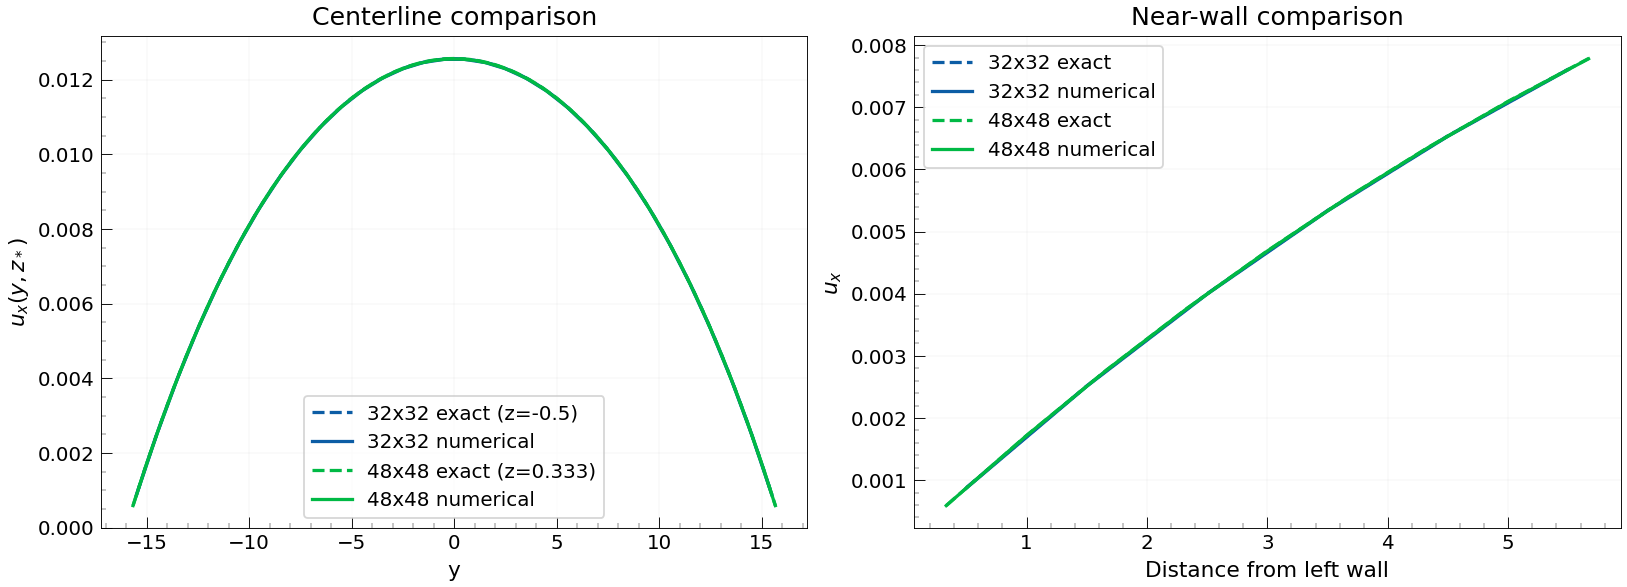

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.5), constrained_layout=True)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, case in enumerate(analysis):
    final = case['final']
    color = colors[idx % len(colors)]
    ax[0].plot(final['center_exact_dense_y'], final['center_exact_dense'], color=color, lw=1.8, ls='--', label=f"{case['label']} exact (z={final['centerline_z']:.3g})")
    ax[0].plot(final['y'], final['center_num'], color=color, lw=1.8, label=f"{case['label']} numerical")

    y = final['y']
    a = final['a']
    eta = y + a
    keep = eta <= min(6.0, 0.35 * (2.0 * a))
    ax[1].plot(eta[keep], final['center_exact'][keep], color=color, lw=1.8, ls='--', label=f"{case['label']} exact")
    ax[1].plot(eta[keep], final['center_num'][keep], color=color, lw=1.8, label=f"{case['label']} numerical")

ax[0].set_title('Centerline comparison')
ax[0].set_xlabel('y')
ax[0].set_ylabel(r'$u_x(y,z_*)$')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].set_title('Near-wall comparison')
ax[1].set_xlabel('Distance from left wall')
ax[1].set_ylabel(r'$u_x$')
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.show()


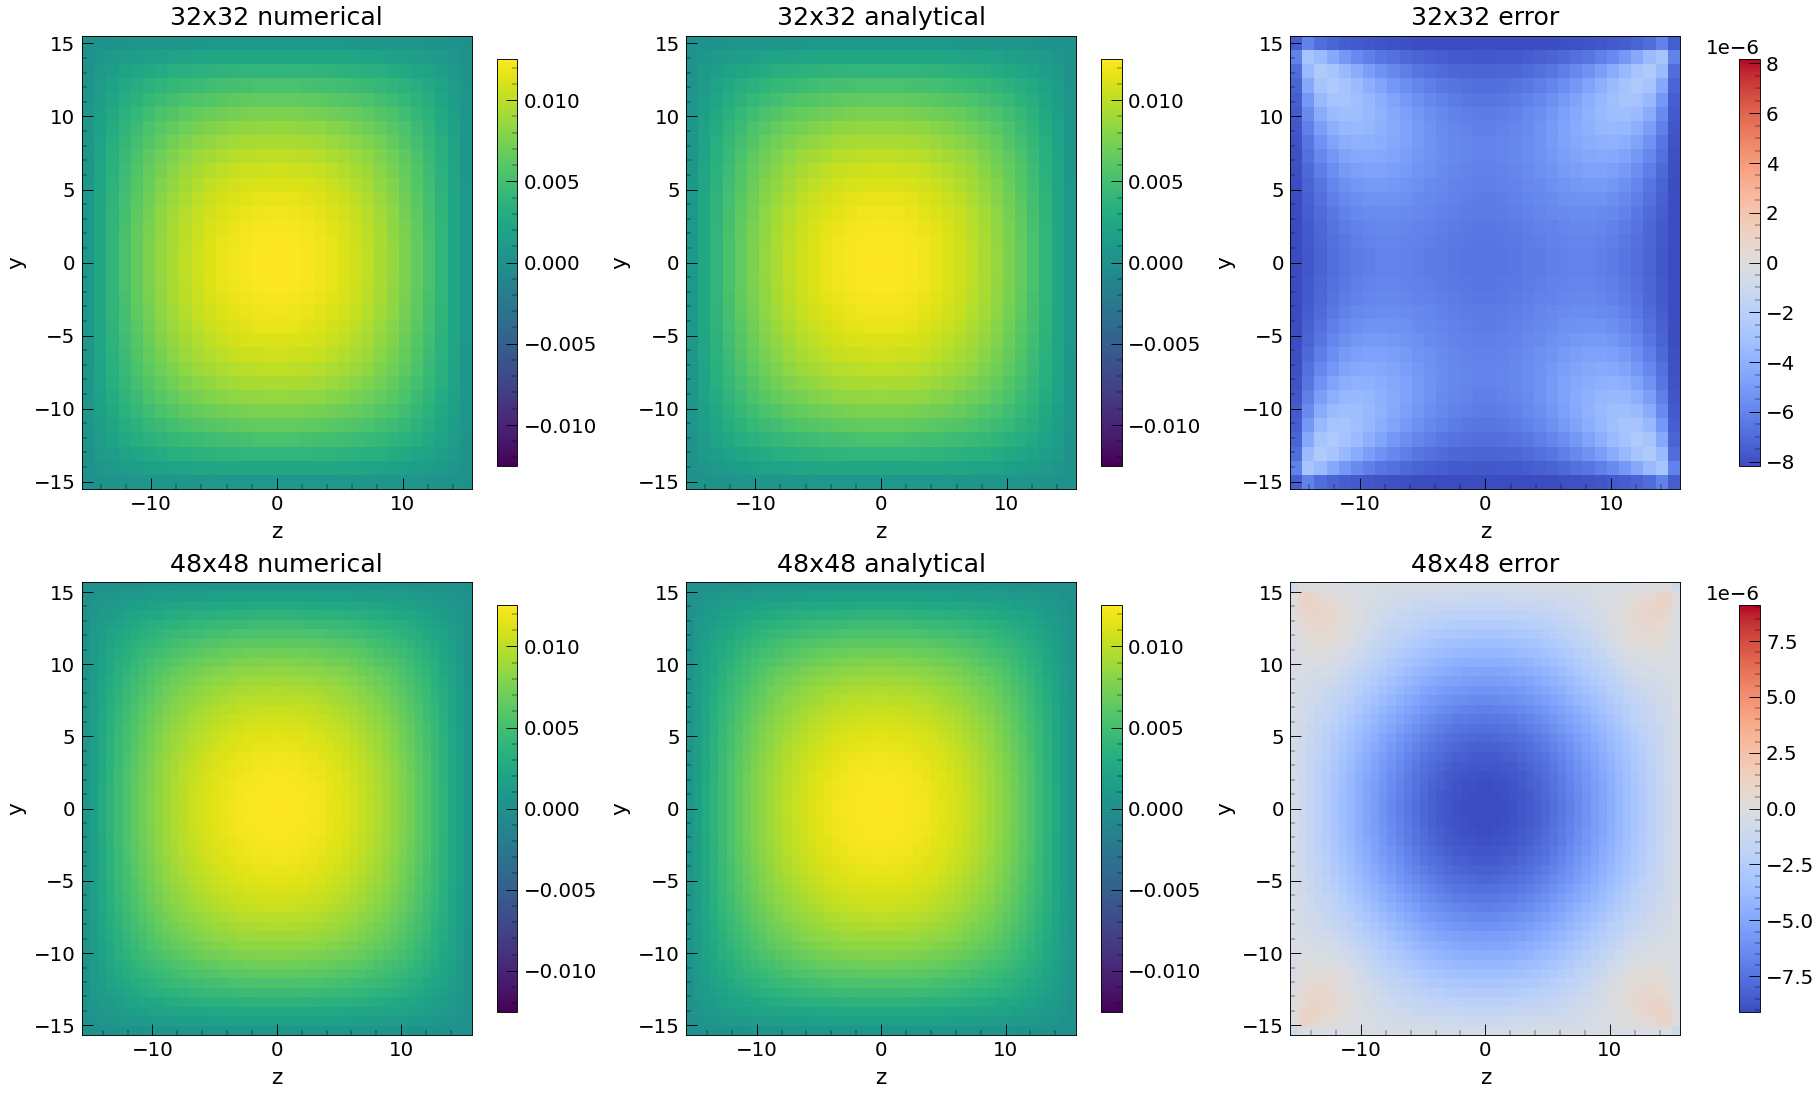

In [5]:
fig, ax = plt.subplots(len(analysis), 3, figsize=(14, 4.2 * len(analysis)), constrained_layout=True)
if len(analysis) == 1:
    ax = np.asarray([ax])

for row, case in enumerate(analysis):
    final = case['final']
    y = final['y']
    z = final['z']
    extent = [float(z[0]), float(z[-1]), float(y[0]), float(y[-1])]
    vmax = max(np.max(np.abs(final['uavg'])), np.max(np.abs(final['uexact'])))
    emax = np.max(np.abs(final['error']))
    fields = [
        (f"{case['label']} numerical", final['uavg'], 'viridis', -vmax, vmax),
        (f"{case['label']} analytical", final['uexact'], 'viridis', -vmax, vmax),
        (f"{case['label']} error", final['error'], 'coolwarm', -emax, emax),
    ]
    for col, (title, arr, cmap, vmin, vmax_local) in enumerate(fields):
        im = ax[row, col].imshow(arr, origin='lower', extent=extent, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax_local, interpolation='nearest')
        ax[row, col].set_title(title)
        ax[row, col].set_xlabel('z')
        ax[row, col].set_ylabel('y')
        fig.colorbar(im, ax=ax[row, col], shrink=0.9)

plt.show()
